## Завдання 1 та 2 рівня складності
### Група вимог_1:
1. Отримання вхідних даних із властивостями, заданими в Лр_1;
2. Визначення показників якості та оптимізація моделі (вибір моделі залежно від
значення показника якості). Показник якості та спосіб оптимізації обрати самостійно.
3. Статистичне навчання поліноміальної моделі за методом найменших квадратів
(МНК – LSM) – поліноміальна регресія для вхідних даних, отриманих в п.1,2. Спосіб
реалізації МНК обрати самостійно;
4. Прогнозування (екстраполяцію) параметрів досліджуваного процесу за «навченою»
у п.5 моделлю на 0,5 інтервалу спостереження (об’єму вибірки);
5. Провести аналіз отриманих результатів та верифікацію розробленого скрипта.

### Група вимог_2:
До функціоналу групи вимог 2 додати:
1. Модель вхідних даних із аномальними вимірами (якщо обрано синтезовані дані для
обробки). Для реальних даних цей пункт пропустикт;
2. Очищення вхідних даних від аномальних вимірів. Спосіб виявлення аномалій та
очищення обрати самостійно;

### Проведення парсингу згідно з методом лабораторної роботи №1 та обробка аномальних даних (пункт 1 з групи вимог №1 та пункт 2 з групи вимог №2)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
from sklearn.preprocessing import StandardScaler
import statsmodels.tsa.seasonal as seas
import statsmodels.api as sm
from bs4 import BeautifulSoup
from pathlib import Path

In [139]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df_full = df[(df['Date'] > '2021-12-31') & (df['Date'] < '2024-12-31')].reset_index(drop=True)
df_full[['Buy', 'Sell']] = df_full[['Buy', 'Sell']].astype(float)
df = df[(df['Date'] > '2021-12-31') & (df['Date'] < '2023-12-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

df

,Date,Buy,Sell
0,2022-01-04,30.9125,30.9350
1,2022-01-05,31.1202,31.1429
2,2022-01-06,31.1298,31.1524
3,2022-01-10,31.0725,31.0923
4,2022-01-11,31.2710,31.2909
...,...,...,...
411,2023-12-25,41.4108,41.4326
412,2023-12-26,41.3733,41.3916
413,2023-12-27,41.9655,41.9837
414,2023-12-28,42.2805,42.2913


In [140]:
print(len(df), len(df_full))

416 677


In [141]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


In [142]:
def clean_anomalies(df, column='Buy', window=10, sigma=3):
    # Cleaning out anomalies function by mean and std
    df_clean = df.copy()
    rolling_mean = df_clean[column].rolling(window=window).mean()
    rolling_std = df_clean[column].rolling(window=window).std()

    upper_bond = rolling_mean + (sigma * rolling_std)
    lower_bond = rolling_mean - (sigma * rolling_std)

    anomalies = df_clean[(df_clean[column] > upper_bond) | (df_clean[column] < lower_bond)]

    df_clean.loc[anomalies.index, column] = np.nan
    df_clean[column] = df_clean[column].interpolate(method='polynomial', order=5)

    return df_clean, anomalies

def clean_anomalies_by_volatility(df, column='Buy', sigma=3):
    # Cleaning out anomalies function percentage change
    df_clean = df.copy()
    df_clean['returns'] = df_clean[column].pct_change()

    returns_mean = df_clean['returns'].mean()
    returns_std = df_clean['returns'].std()

    upper_threshold = returns_mean + (sigma * returns_std)
    lower_threshold = returns_mean - (sigma * returns_std)

    anomaly_mask = (df_clean['returns'] > upper_threshold) | (df_clean['returns'] < lower_threshold)
    anomalies = df_clean[anomaly_mask]

    df_clean.loc[anomaly_mask, column] = np.nan
    df_clean[column] = df_clean[column].interpolate(method='polynomial', order=5)

    return df_clean.drop(columns=['returns']), anomalies

def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')

def models_resid_verification(dtf, resid_real, resid_synthetic):
    # Function for models resid verification from previous laboratorium(maybe will be useful in future)
    print(dtf[['Synthetic_Buy', 'Buy']].describe())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    ax[0].hist(resid_real, label="Real", edgecolor='black')
    ax[0].set_xlabel('Resid of the real data')
    ax[0].legend(loc="best")

    ax[1].hist(resid_synthetic, label="Synthetic", edgecolor='black')
    ax[1].set_xlabel('Resid of the synthetic data')
    ax[1].legend(loc="best")
    plt.show()

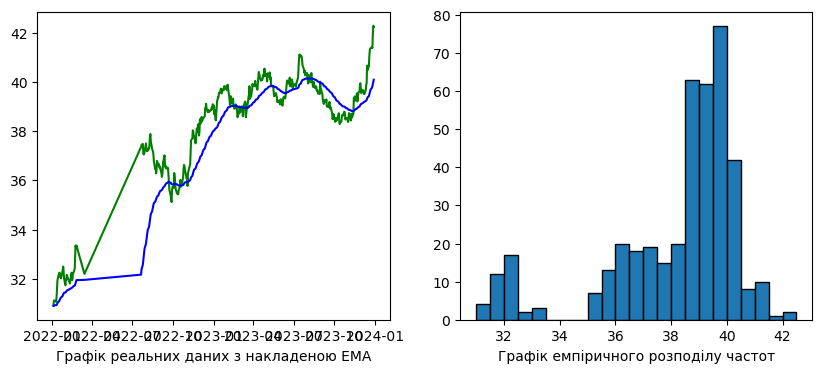

In [143]:
# Got anomalies data, but since it's currency price for buy/sell - there will be no major anomalies, which will be the reason to continue laboratorium with my main dataframe - df
df_clean, anomalies_buy = clean_anomalies(df, 'Buy')
df_clean, anomalies_sell = clean_anomalies(df_clean, 'Sell')
draw_plots(df, 'Date', 'Buy')

In [144]:
print('Anomalies: ')
anomalies_buy[['Date', 'Buy']].join(anomalies_sell[['Sell']], lsuffix='_buy', rsuffix='_sell', how='left')

Anomalies: 


,Date,Buy,Sell


In [145]:
df_clean_1, anomalies_buy = clean_anomalies_by_volatility(df, 'Buy')
df_clean_1, anomalies_sell = clean_anomalies_by_volatility(df_clean_1, 'Sell')

In [146]:
print('Anomalies by volatility: ')
# pd.concat([anomalies_buy.drop('Sell', axis=1), anomalies_sell.drop('Buy', axis=1)])
# pd.concat([anomalies_buy, anomalies_sell])
anomalies_buy[['Date', 'Buy', 'returns']].join(anomalies_sell[['Sell', 'returns']], lsuffix='_buy', rsuffix='_sell', how='left')

Anomalies by volatility: 


,Date,Buy,returns_buy,Sell,returns_sell
38,2022-03-15,32.2042,-0.034531,32.5345,-0.047005
39,2022-07-21,37.3584,0.160047,37.7320,0.159753


In [189]:
def optimize_polynomial_degree(df, col='Buy', max_degree=10):
    y = df[col]
    x = np.arange(len(df))

    results_stats = []

    print(f"{'Degree':<10} | {'AIC':<15} | {'BIC':<15} | {'R-squared':<15}")

    best_aic = float('inf')
    best_model_results = None

    for deg in range(1, max_degree + 1):
        X_poly = np.vander(x, deg + 1, increasing=True)

        model = sm.OLS(y, X_poly)
        results = model.fit()

        aic = results.aic
        bic = results.bic
        r2 = results.rsquared

        results_stats.append({'degree': deg, 'AIC': aic, 'BIC': bic, 'R2': r2})
        print(f"{deg:<10} | {aic:<15.4f} | {bic:<15.4f} | {r2:<15.4f}")

        if aic < best_aic:
            best_aic = aic
            best_model_results = results

    return pd.DataFrame(results_stats), best_model_results

Degree     | AIC             | BIC             | R-squared      
1          | 825.9067        | 833.9681        | 0.5777         
2          | 494.2550        | 506.3471        | 0.8107         
3          | 418.9199        | 435.0426        | 0.8428         
4          | 413.5018        | 433.6552        | 0.8456         
5          | 301.6808        | 325.8649        | 0.8825         
6          | 752.4923        | 776.6764        | 0.6528         
7          | 1042.1889       | 1062.3423       | 0.3000         
8          | 1044.1047       | 1068.2888       | 0.3001         
9          | 1046.0508       | 1074.2656       | 0.3002         
10         | 1047.9454       | 1080.1909       | 0.3004         


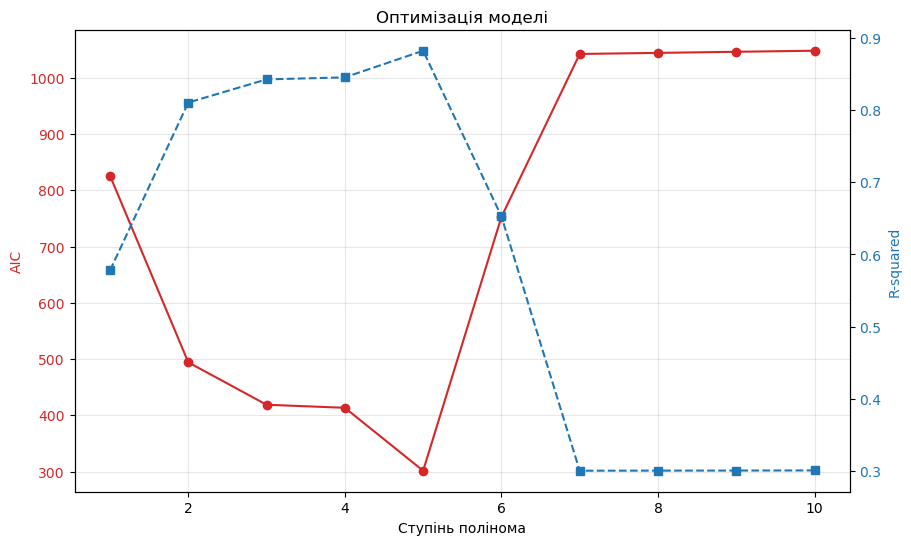

In [190]:
# Normality of data
norm_df = df.copy().drop('Sell', axis=1)
norm_df[['Buy']] = StandardScaler().fit_transform(df[['Buy']])

# Getting results for the optimal polynomial degree
stats_df, best_model = optimize_polynomial_degree(norm_df, col='Buy')

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Ступінь полінома')
ax1.set_ylabel('AIC', color=color)
ax1.plot(stats_df['degree'], stats_df['AIC'], marker='o', color=color, label='AIC')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('R-squared', color=color)
ax2.plot(stats_df['degree'], stats_df['R2'], marker='s', linestyle='--', color=color, label='R^2')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Оптимізація моделі')
plt.show()

In [204]:
# Getting predictions for 100 days ahead
x_future = np.arange(len(norm_df) + 100)
optimal_degree = 5

X_future_poly = np.vander(x_future, optimal_degree + 1, increasing=True)

prediction = best_model.predict(X_future_poly)
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    Buy   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     616.0
Date:                Wed, 19 Nov 2025   Prob (F-statistic):          4.04e-188
Time:                        18:42:58   Log-Likelihood:                -144.84
No. Observations:                 416   AIC:                             301.7
Df Residuals:                     410   BIC:                             325.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3129      0.099    -33.308      0.000      -3.508      -3.117
x1             0.0732      0.005     15.043      0.000       0.064       0.083
x2            -0.0008   7.28e-05    -11.040      0.000      -0.001      -0.001
x3          4.759e-06   4.46e-07     10.680      0.000    3.88e-06    5.64e-06
x4         -1.302e-08   1.18e-09    -10.990      0.000   -1.53e-08   -1.07e-08
x5           1.29e-11   1.14e-12     11.359      0.000    1.07e-11    1.51e-11
==============================================================================
Omnibus:                       10.069   Durbin-Watson:                   0.158
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               14.946
Skew:                           0.172   Prob(JB):                     0.000568
Kurtosis:                       3.862   Cond. No.                     2.19e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.19e+13. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [195]:
prediction

array([-3.31286292e+00, -3.24050234e+00, -3.16972175e+00, -3.10049307e+00,
       -3.03278852e+00, -2.96658062e+00, -2.90184222e+00, -2.83854644e+00,
       -2.77666673e+00, -2.71617683e+00, -2.65705078e+00, -2.59926292e+00,
       -2.54278790e+00, -2.48760064e+00, -2.43367637e+00, -2.38099061e+00,
       -2.32951917e+00, -2.27923815e+00, -2.23012393e+00, -2.18215319e+00,
       -2.13530289e+00, -2.08955026e+00, -2.04487283e+00, -2.00124839e+00,
       -1.95865503e+00, -1.91707110e+00, -1.87647524e+00, -1.83684635e+00,
       -1.79816360e+00, -1.76040645e+00, -1.72355461e+00, -1.68758807e+00,
       -1.65248707e+00, -1.61823213e+00, -1.58480403e+00, -1.55218380e+00,
       -1.52035276e+00, -1.48929244e+00, -1.45898466e+00, -1.42941150e+00,
       -1.40055528e+00, -1.37239856e+00, -1.34492418e+00, -1.31811520e+00,
       -1.29195494e+00, -1.26642698e+00, -1.24151513e+00, -1.21720342e+00,
       -1.19347617e+00, -1.17031791e+00, -1.14771340e+00, -1.12564765e+00,
       -1.10410591e+00, -

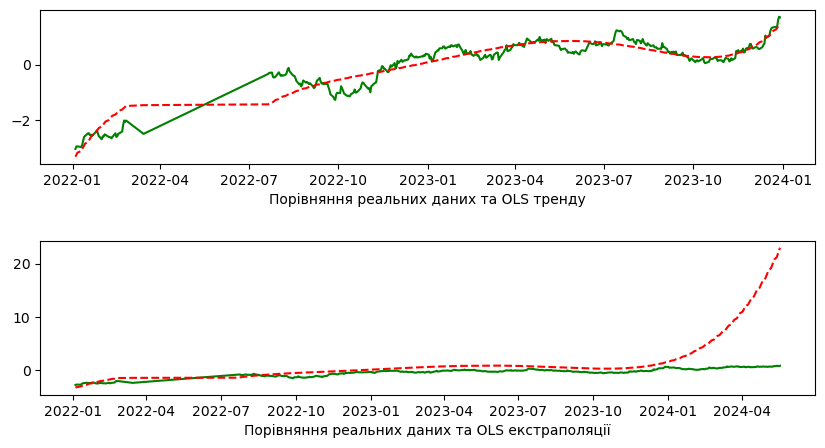

In [203]:
# Normality of 'full dataset', which contains information about the last days data, so we will be able to compare extrapolation results
norm_full_df = df_full.copy().drop('Sell', axis=1)
norm_full_df[['Buy']] = StandardScaler().fit_transform(norm_full_df[['Buy']])

fig, ax = plt.subplots(nrows=2, figsize=(10, 5))
ax[0].plot(norm_df['Date'], norm_df['Buy'], label='Реальні дані', color='g')
ax[0].plot(norm_df['Date'], prediction[:len(norm_df)], label='OLS екстраполяція', color='r', linestyle='--')
ax[0].set_xlabel('Порівняння реальних даних та OLS тренду')

ax[1].plot(norm_full_df['Date'].iloc[:len(prediction)], norm_full_df['Buy'].iloc[:len(prediction)], label='Реальні дані', color='g')
ax[1].plot(norm_full_df['Date'].iloc[:len(prediction)], prediction, label='OLS екстраполяція', color='r', linestyle='--')
ax[1].set_xlabel('Порівняння реальних даних та OLS екстраполяції')

plt.subplots_adjust(hspace=0.5)
plt.show()